In [1]:
%matplotlib notebook

import numpy as np
import json
import math
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
#from numpy.random import seed 
#seed(2)
#tf.random.set_seed(9)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU,Dense, Dropout, Flatten, Input, BatchNormalization, Reshape, UpSampling1D, Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K 

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,Binarizer

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score,f1_score

In [2]:
fp_list = ['combine']

class Data():
    
    def __init__(self, fp, pos_neg):
        
        self.fp = fp
        self.pos_neg = pos_neg
        
        if self.pos_neg == 'pos':
            self.load_pos_data()
            self.shuffle()
            
        elif self.pos_neg == 'neg':
            self.load_neg_data()
            self.shuffle()
    

    def load_pos_data(self):
        with open('{}.json'.format(self.fp), 'r') as file:
            temp = json.load(file)
        positive_index = [i for i in range(len(temp['y'])) if temp['y'][i] == [1,0]]
        self.y = np.array([temp['y'][i] for i in positive_index])
        self.x = np.array([temp['x'][i] for i in positive_index])
        self.x = self.x.reshape(self.x.shape[0], self.x.shape[1],1)
        self.z = self.x.reshape(self.x.shape[0], self.x.shape[1])
        self.m = len(positive_index)
        self.n = self.x.shape[1]
        print('Shape x: {}'.format(self.x.shape))
        print('Shape y: {}'.format(self.y.shape))
    
    def load_neg_data(self):
        with open('{}.json'.format(self.fp), 'r') as file:
            temp = json.load(file)
        negative_index = [i for i in range(len(temp['y'])) if temp['y'][i] == [0,1]]
        self.y = np.array([temp['y'][i] for i in negative_index])
        self.x = np.array([temp['x'][i] for i in negative_index])
        self.x = self.x.reshape(self.x.shape[0], self.x.shape[1],1)
        self.z = self.x.reshape(self.x.shape[0], self.x.shape[1])
        self.m = len(negative_index)
        self.n = self.x.shape[1]
        print('Shape x: {}'.format(self.x.shape))
        print('Shape y: {}'.format(self.y.shape))
    
    def shuffle(self):
        temp_x = np.zeros(self.x.shape)
        index = list(range(self.m))
        np.random.shuffle(index)
        for x in range(self.m):
            value = int(index[int(x)])
            temp_x[x,:] = self.x[value,:]
        self.x = temp_x
                                  
    def convert(self, string, as_array=True):
        letter_list = list('abcdef')
        jump = 1
        fp = []
        code = [0]*len(list(string))*4
        for index in range(len(list(string))):
            index += jump
            value = string[index].lower()
            if value in letter_list:
                value = letter_list.index(value) + 10
            index = (index-jump)*4
            value = int(value)
            code[index] = 1*value%2
            code[index+1] = 1*math.floor(value/2)%2
            code[index+2] = 1*math.floor(value/4)%2
            code[index+3] = 1*math.floor(value/8)%2
            jump *= -1
        if as_array == True:
            code = np.array(code)
        return code

In [3]:
pos_data=Data(fp='combine', pos_neg='pos')
neg_data=Data(fp='combine', pos_neg='neg')

Shape x: (7002, 168, 1)
Shape y: (7002, 2)
Shape x: (9998, 168, 1)
Shape y: (9998, 2)


In [4]:
batch_size=7002
    #get real compounds
    #index = np.random.choice(range(pos_data.m), size=(batch_size), replace=False)
train_x_real = pos_data.x
train_y_real = np.zeros([batch_size,2])
train_y_real[:,0] = 1
    #d_loss_real = d.train_on_batch(train_x_real,train_y_real)

    #get decoys
index1 = np.random.choice(range(neg_data.m), size=(batch_size), replace=False)
train_x_decoy = neg_data.x[index1]
train_y_decoy = np.zeros([batch_size,2])
train_y_decoy[:,1] = 1
    #d_loss_decoy = d.train_on_batch(train_x_real,train_y_real)

    # d_loss = d_loss_real + d_loss_decoy
    # loss_d_epoch.append(d_loss[0])
X = np.concatenate((train_x_real, train_x_decoy))
y = np.zeros([2*batch_size,2])
y[0:(batch_size),0] = 1
y[(batch_size):,1] = 1
    
df_y = pd.DataFrame(y)
y_new = df_y.iloc[:,0]

In [5]:
cv = StratifiedKFold(n_splits=10)

In [6]:
def calc_precision(y_true, y_pred):
    true_pos = calc_true_positive(y_true, y_pred)
    return true_pos/np.sum(y_pred, axis=0)

def calc_recall(y_true, y_pred):
    true_pos = calc_true_positive(y_true, y_pred)
    return true_pos/np.sum(y_true, axis=0)

def calc_true_positive(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply(y_true,y_pred), axis=0)
    else:
        return tf.reduce_sum(y_true*y_pred)

def calc_true_negative(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_true),(1-y_pred)), axis=0)
    else:
        return tf.reduce_sum((1-y_true)*(1-y_pred))

def calc_false_positive(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_true),(y_pred)), axis=0)
    else:
        return tf.reduce_sum((1-y_true)*y_pred)

def calc_false_negative(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_pred),y_true), axis=0)
    else:
        return tf.reduce_sum(y_true*(1-y_pred))

In [ ]:
mean_fpr = np.linspace(0, 1, 100)
tprs=[]
tprs_all=[]
fprs=[]
aucs=[]
accs=[]
f1s=[]
TPs=[]
TNs=[]
FPs=[]
FNs=[]
precisions=[]
recalls=[]

for train,test in cv.split(X,y_new):


    model = Sequential()
    model.add(Conv1D(8, kernel_size=3,
                     strides=1,
                     activation='relu',
                     padding='valid',
                     input_shape=[168,1],
                     kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(16, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(16, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(2, activation='softmax', kernel_regularizer=regularizers.l2(0.01)))

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=keras.optimizers.Adam(lr=0.00045),
                  metrics=['accuracy'])



    model.fit(X[train],y[train],
                 batch_size=batch_size,
                 epochs=80,
                 verbose=1,
                 validation_data=(X[test],y[test]))
    pred_prob = model.predict(X[test])[:,0]
    pred = model.predict(X[test])[:,0]
    y_pred = np.round(pred)
    print(y_pred)
    print(pred_prob)
    fpr, tpr, thresholds = roc_curve(y_new[test],pred_prob)
    roc_auc = auc(fpr,tpr)
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs_all.append(interp_tpr)

    acc = accuracy_score(y_new[test], y_pred)
    f1 = f1_score(y_new[test], y_pred)
    accs.append(acc)
    f1s.append(f1)
    
    TP=calc_true_positive(y_new[test], y_pred)
    TN=calc_true_negative(y_new[test], y_pred)
    FP=calc_false_positive(y_new[test], y_pred)
    FN=calc_false_negative(y_new[test], y_pred)
    TPs.append(TP)
    TNs.append(TN)
    FPs.append(FP)
    FNs.append(FN)

    prec = calc_precision(y_new[test], y_pred)
    recall=calc_recall(y_new[test],y_pred)

    precisions.append(prec)
    recalls.append(recall)
    
    del model
    K.clear_session()


Epoch 1/80
2/2 [==============================] - 5s 2s/step - loss: 9.7875 - accuracy: 0.4981 - val_loss: 9.6254 - val_accuracy: 0.4996
Epoch 2/80
2/2 [==============================] - 3s 1s/step - loss: 9.5798 - accuracy: 0.4912 - val_loss: 9.4204 - val_accuracy: 0.4996
Epoch 3/80
2/2 [==============================] - 3s 1s/step - loss: 9.3754 - accuracy: 0.4954 - val_loss: 9.2189 - val_accuracy: 0.4996
Epoch 4/80
2/2 [==============================] - 3s 1s/step - loss: 9.1745 - accuracy: 0.5034 - val_loss: 9.0209 - val_accuracy: 0.5004
Epoch 5/80
2/2 [==============================] - 3s 1s/step - loss: 8.9772 - accuracy: 0.5254 - val_loss: 8.8265 - val_accuracy: 0.5004
Epoch 6/80
2/2 [==============================] - 3s 1s/step - loss: 8.7834 - accuracy: 0.5553 - val_loss: 8.6357 - val_accuracy: 0.5004
Epoch 7/80
2/2 [==============================] - 3s 1s/step - loss: 8.5934 - accuracy: 0.5218 - val_loss: 8.4486 - val_accuracy: 0.5004
Epoch 8/80
2/2 [=========================

2/2 [==============================] - 3s 1s/step - loss: 2.7924 - accuracy: 0.6052 - val_loss: 2.7790 - val_accuracy: 0.5025
Epoch 61/80
2/2 [==============================] - 3s 1s/step - loss: 2.7382 - accuracy: 0.6076 - val_loss: 2.7268 - val_accuracy: 0.5046
Epoch 62/80
2/2 [==============================] - 2s 1s/step - loss: 2.6850 - accuracy: 0.6129 - val_loss: 2.6785 - val_accuracy: 0.5025
Epoch 63/80
2/2 [==============================] - 2s 924ms/step - loss: 2.6355 - accuracy: 0.6058 - val_loss: 2.6277 - val_accuracy: 0.5046
Epoch 64/80
2/2 [==============================] - 2s 893ms/step - loss: 2.5847 - accuracy: 0.6092 - val_loss: 2.5783 - val_accuracy: 0.5075
Epoch 65/80
2/2 [==============================] - 2s 1s/step - loss: 2.5363 - accuracy: 0.6091 - val_loss: 2.5309 - val_accuracy: 0.5061
Epoch 66/80
2/2 [==============================] - 1s 709ms/step - loss: 2.4893 - accuracy: 0.6088 - val_loss: 2.4860 - val_accuracy: 0.5061
Epoch 67/80
2/2 [====================

Epoch 37/80
2/2 [==============================] - 3s 1s/step - loss: 4.4807 - accuracy: 0.5818 - val_loss: 4.4091 - val_accuracy: 0.5004
Epoch 38/80
2/2 [==============================] - 3s 1s/step - loss: 4.3870 - accuracy: 0.5846 - val_loss: 4.3173 - val_accuracy: 0.5004
Epoch 39/80
2/2 [==============================] - 2s 1s/step - loss: 4.2954 - accuracy: 0.5827 - val_loss: 4.2275 - val_accuracy: 0.5004
Epoch 40/80
2/2 [==============================] - 2s 1s/step - loss: 4.2061 - accuracy: 0.5853 - val_loss: 4.1399 - val_accuracy: 0.5004
Epoch 41/80
2/2 [==============================] - 3s 1s/step - loss: 4.1190 - accuracy: 0.5886 - val_loss: 4.0545 - val_accuracy: 0.5004
Epoch 42/80
2/2 [==============================] - 3s 1s/step - loss: 4.0338 - accuracy: 0.5875 - val_loss: 3.9710 - val_accuracy: 0.5004
Epoch 43/80
2/2 [==============================] - 2s 1s/step - loss: 3.9506 - accuracy: 0.5949 - val_loss: 3.8896 - val_accuracy: 0.5004
Epoch 44/80
2/2 [=================

2/2 [==============================] - 2s 1s/step - loss: 7.2173 - accuracy: 0.5575 - val_loss: 7.0960 - val_accuracy: 0.4996
Epoch 16/80
2/2 [==============================] - 2s 977ms/step - loss: 7.0599 - accuracy: 0.5592 - val_loss: 6.9415 - val_accuracy: 0.4996
Epoch 17/80
2/2 [==============================] - 2s 1s/step - loss: 6.9060 - accuracy: 0.5682 - val_loss: 6.7905 - val_accuracy: 0.4996
Epoch 18/80
2/2 [==============================] - 2s 1s/step - loss: 6.7557 - accuracy: 0.5615 - val_loss: 6.6429 - val_accuracy: 0.4996
Epoch 19/80
2/2 [==============================] - 2s 1s/step - loss: 6.6087 - accuracy: 0.5568 - val_loss: 6.4985 - val_accuracy: 0.4996
Epoch 20/80
2/2 [==============================] - 2s 1s/step - loss: 6.4651 - accuracy: 0.5638 - val_loss: 6.3576 - val_accuracy: 0.4996
Epoch 21/80
2/2 [==============================] - 2s 1s/step - loss: 6.3247 - accuracy: 0.5659 - val_loss: 6.2198 - val_accuracy: 0.4996
Epoch 22/80
2/2 [==========================

Epoch 74/80
2/2 [==============================] - 2s 1s/step - loss: 2.1571 - accuracy: 0.6067 - val_loss: 2.1563 - val_accuracy: 0.5075
Epoch 75/80
2/2 [==============================] - 2s 1s/step - loss: 2.1194 - accuracy: 0.6068 - val_loss: 2.1085 - val_accuracy: 0.5303
Epoch 76/80
2/2 [==============================] - 2s 1s/step - loss: 2.0813 - accuracy: 0.6095 - val_loss: 2.0786 - val_accuracy: 0.5196
Epoch 77/80
2/2 [==============================] - 2s 997ms/step - loss: 2.0468 - accuracy: 0.6060 - val_loss: 2.0378 - val_accuracy: 0.5296
Epoch 78/80
2/2 [==============================] - 2s 1s/step - loss: 2.0127 - accuracy: 0.6099 - val_loss: 2.0037 - val_accuracy: 0.5318
Epoch 79/80
2/2 [==============================] - 2s 1s/step - loss: 1.9763 - accuracy: 0.6134 - val_loss: 1.9784 - val_accuracy: 0.5211
Epoch 80/80
2/2 [==============================] - 2s 1s/step - loss: 1.9443 - accuracy: 0.6111 - val_loss: 1.9341 - val_accuracy: 0.5546
[1. 0. 1. ... 1. 0. 1.]
[0.6556

...

2/2 [==============================] - 2s 770ms/step - loss: 3.7595 - accuracy: 0.6023 - val_loss: 3.7300 - val_accuracy: 0.5071
Epoch 46/80
2/2 [==============================] - 2s 762ms/step - loss: 3.6821 - accuracy: 0.6016 - val_loss: 3.6490 - val_accuracy: 0.5214
Epoch 47/80
2/2 [==============================] - 2s 1s/step - loss: 3.6049 - accuracy: 0.6070 - val_loss: 3.5691 - val_accuracy: 0.5443
Epoch 48/80
2/2 [==============================] - 2s 1s/step - loss: 3.5320 - accuracy: 0.6088 - val_loss: 3.5076 - val_accuracy: 0.5171
Epoch 49/80
2/2 [==============================] - 2s 900ms/step - loss: 3.4610 - accuracy: 0.6039 - val_loss: 3.4309 - val_accuracy: 0.5336
Epoch 50/80
2/2 [==============================] - 2s 1s/step - loss: 3.3898 - accuracy: 0.6096 - val_loss: 3.3563 - val_accuracy: 0.5493
Epoch 51/80
2/2 [==============================] - 2s 1s/step - loss: 3.3223 - accuracy: 0.6073 - val_loss: 3.2969 - val_accuracy: 0.5343
Epoch 52/80
2/2 [====================

2/2 [==============================] - 1s 627ms/step - loss: 6.0441 - accuracy: 0.5795 - val_loss: 5.9454 - val_accuracy: 0.5000
Epoch 24/80
2/2 [==============================] - 2s 753ms/step - loss: 5.9131 - accuracy: 0.5889 - val_loss: 5.8172 - val_accuracy: 0.5000
Epoch 25/80
2/2 [==============================] - 1s 619ms/step - loss: 5.7853 - accuracy: 0.5870 - val_loss: 5.6921 - val_accuracy: 0.5000
Epoch 26/80
2/2 [==============================] - 1s 715ms/step - loss: 5.6603 - accuracy: 0.5823 - val_loss: 5.5699 - val_accuracy: 0.5000
Epoch 27/80
2/2 [==============================] - 1s 724ms/step - loss: 5.5384 - accuracy: 0.5876 - val_loss: 5.4504 - val_accuracy: 0.5000
Epoch 28/80
2/2 [==============================] - 1s 694ms/step - loss: 5.4195 - accuracy: 0.5877 - val_loss: 5.3338 - val_accuracy: 0.5000
Epoch 29/80
2/2 [==============================] - 1s 740ms/step - loss: 5.3032 - accuracy: 0.5913 - val_loss: 5.2202 - val_accuracy: 0.5000
Epoch 30/80
2/2 [========

Epoch 1/80
2/2 [==============================] - 2s 1s/step - loss: 9.7529 - accuracy: 0.5005 - val_loss: 9.5917 - val_accuracy: 0.5000
Epoch 2/80
2/2 [==============================] - 2s 755ms/step - loss: 9.5456 - accuracy: 0.5332 - val_loss: 9.3871 - val_accuracy: 0.5000
Epoch 3/80
2/2 [==============================] - 1s 656ms/step - loss: 9.3416 - accuracy: 0.5537 - val_loss: 9.1860 - val_accuracy: 0.5000
Epoch 4/80
2/2 [==============================] - 1s 707ms/step - loss: 9.1410 - accuracy: 0.5396 - val_loss: 8.9884 - val_accuracy: 0.5000
Epoch 5/80
2/2 [==============================] - 1s 706ms/step - loss: 8.9440 - accuracy: 0.5309 - val_loss: 8.7943 - val_accuracy: 0.5000
Epoch 6/80
2/2 [==============================] - 1s 664ms/step - loss: 8.7506 - accuracy: 0.5332 - val_loss: 8.6039 - val_accuracy: 0.5000
Epoch 7/80
2/2 [==============================] - 1s 691ms/step - loss: 8.5608 - accuracy: 0.5425 - val_loss: 8.4172 - val_accuracy: 0.5000
Epoch 8/80
2/2 [=======

2/2 [==============================] - 1s 369ms/step - loss: 2.8240 - accuracy: 0.6106 - val_loss: 2.7924 - val_accuracy: 0.5736
Epoch 60/80
2/2 [==============================] - 1s 383ms/step - loss: 2.7679 - accuracy: 0.6150 - val_loss: 2.7393 - val_accuracy: 0.5721
Epoch 61/80
2/2 [==============================] - 1s 384ms/step - loss: 2.7156 - accuracy: 0.6101 - val_loss: 2.6910 - val_accuracy: 0.5550
Epoch 62/80
2/2 [==============================] - 1s 388ms/step - loss: 2.6640 - accuracy: 0.6112 - val_loss: 2.6361 - val_accuracy: 0.5714
Epoch 63/80
2/2 [==============================] - 1s 379ms/step - loss: 2.6130 - accuracy: 0.6110 - val_loss: 2.5837 - val_accuracy: 0.5843
Epoch 64/80
2/2 [==============================] - 1s 382ms/step - loss: 2.5650 - accuracy: 0.6114 - val_loss: 2.5418 - val_accuracy: 0.5621
Epoch 65/80
2/2 [==============================] - 1s 388ms/step - loss: 2.5161 - accuracy: 0.6082 - val_loss: 2.4907 - val_accuracy: 0.5764
Epoch 66/80
2/2 [========

2/2 [==============================] - 1s 412ms/step - loss: 4.5731 - accuracy: 0.5975 - val_loss: 4.5000 - val_accuracy: 0.5493
Epoch 37/80
2/2 [==============================] - 1s 379ms/step - loss: 4.4768 - accuracy: 0.5974 - val_loss: 4.4065 - val_accuracy: 0.5264
Epoch 38/80
2/2 [==============================] - 1s 388ms/step - loss: 4.3826 - accuracy: 0.5963 - val_loss: 4.3147 - val_accuracy: 0.5221
Epoch 39/80
2/2 [==============================] - 1s 371ms/step - loss: 4.2899 - accuracy: 0.5970 - val_loss: 4.2243 - val_accuracy: 0.5264
Epoch 40/80
2/2 [==============================] - 1s 357ms/step - loss: 4.2022 - accuracy: 0.5924 - val_loss: 4.1341 - val_accuracy: 0.5750
Epoch 41/80
2/2 [==============================] - 1s 388ms/step - loss: 4.1136 - accuracy: 0.6025 - val_loss: 4.0478 - val_accuracy: 0.5793
Epoch 42/80
2/2 [==============================] - 1s 374ms/step - loss: 4.0278 - accuracy: 0.5979 - val_loss: 3.9660 - val_accuracy: 0.5493
Epoch 43/80
2/2 [========

<IPython.core.display.Javascript object>


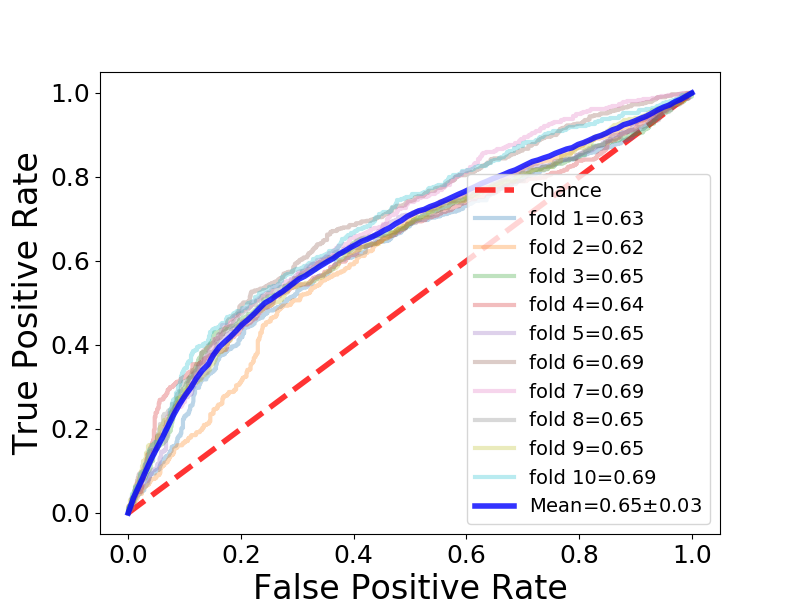

In [8]:
fig, ax = plt.subplots(figsize = (8,6))

ax.plot([0, 1], [0, 1], linestyle='--', color='r',
        label='Chance', alpha=.8, linewidth = 4)

for j in range(10):
    ax.plot(fprs[j], tprs[j], label='fold {0}={1:0.2f}'.format(j+1, aucs[j]), alpha=0.3, linewidth = 3)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean(tprs_all, axis=0)
mean_tpr[-1] = 1.0
mean_auc_svm = auc(mean_fpr, mean_tpr)
std_auc_svm = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean=%0.2f$\pm$%0.2f' % (mean_auc_svm, std_auc_svm),
        alpha=.8, linewidth = 4)

std_tpr = np.std(tprs_all, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
#ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
#                label=r'$\pm$ 1 std. dev.')
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])

ax.legend(loc="lower right")

plt.xlabel('False Positive Rate', fontsize=24)
plt.ylabel('True Positive Rate', fontsize=24)
plt.legend(loc="lower right", prop={"size":14})
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('maccs_D_vggnet16.pdf',dpi=600)
plt.show()